In [33]:
pip install tensorflow keras numpy matplotlib


Note: you may need to restart the kernel to use updated packages.


In [34]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


In [38]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Corrected paths
train_dir = r"C:\Users\kavya\Desktop\Fish disease\Freshwater Fish Disease Aquaculture in south asia\Train"
val_dir = r"C:\Users\kavya\Desktop\Fish disease\Freshwater Fish Disease Aquaculture in south asia\Val"

# Create ImageDataGenerator for augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.3,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_datagen = ImageDataGenerator(rescale=1./255)

# Load images in batches
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

num_classes = len(train_generator.class_indices)  # Automatically detect class count
print("Total Classes:", num_classes)


Found 719 images belonging to 7 classes.
Found 1028 images belonging to 7 classes.
Total Classes: 7


In [39]:
# Load the VGG16 model (pretrained on ImageNet)
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification layers
x = Flatten()(base_model.output)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
output_layer = Dense(num_classes, activation="softmax")(x)  # Number of classes dynamically

# Create model
model = Model(inputs=base_model.input, outputs=output_layer)

# Compile model
model.compile(optimizer=Adam(learning_rate=0.0005), loss="categorical_crossentropy", metrics=["accuracy"])

# Print summary
model.summary()


58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 23s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           90

 Total params: 21,171,271 (80.76 MB)

 Trainable params: 6,456,583 (24.63 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [40]:
# Early stopping (Stop if validation accuracy doesn’t improve for 5 epochs)
early_stopping = EarlyStopping(monitor="val_accuracy", patience=5, restore_best_weights=True)

# Train the model
history = model.fit(
    train_generator,
    epochs=50,
    validation_data=val_generator,
    callbacks=[early_stopping]
)


c:\Users\kavya\Desktop\Fish disease\venv\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 254s 11s/step - accuracy: 0.1650 - loss: 2.6399 - val_accuracy: 0.2588 - val_loss: 1.8808
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 250s 11s/step - accuracy: 0.1708 - loss: 1.9821 - val_accuracy: 0.2481 - val_loss: 1.9060
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 251s 11s/step - accuracy: 0.1954 - loss: 1.9502 - val_accuracy: 0.2267 - val_loss: 1.9256
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 254s 11s/step - accuracy: 0.1920 - loss: 1.9275 - val_accuracy: 0.2714 - val_loss: 1.8876
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 253s 11s/step - accuracy: 0.2068 - loss: 1.9049 - val_accuracy: 0.2743 - val_loss: 1.8468
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 255s 11s/step - accuracy: 0.2331 - loss: 1.8867 - val_accuracy: 0.3414 - val_loss: 1.8498
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 263s 12s/step - accuracy: 0.2374 - loss: 1.8533 - val_accuracy: 0.3531 - val_loss: 1.8129
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 262s 12s/step - accuracy: 0.2426 - loss: 1.8735 - val_accuracy: 0.

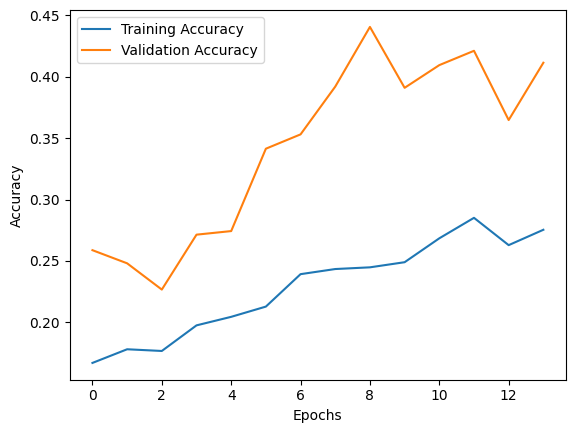

In [41]:
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


In [42]:
model.save("fish_disease_vgg16_model.h5")
print("Model saved successfully!")


Model saved successfully!


In [49]:
img = image.load_img(img_path, target_size=(224, 224))  # Change target_size if needed


In [50]:
img = image.load_img(img_path, target_size=(299, 299))


In [43]:
from tensorflow.keras.models import load_model

model = load_model("fish_disease_vgg16_model.h5")
print("Model loaded successfully!")


Model loaded successfully!


In [48]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_fish_disease(image_path, model):
    # Load and preprocess image
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img) / 255.0  # Normalize
    img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

    # Make prediction
    prediction = model.predict(img_array)
    predicted_class = np.argmax(prediction)  # Get the class with highest probability
    
    # Ensure train_generator is defined before calling .class_indices
    if 'train_generator' in globals():
        class_labels = list(train_generator.class_indices.keys())  # Get class names
        return class_labels[predicted_class]
    else:
        return "Error: train_generator is not defined."

# Example prediction
image_path = r"C:\Users\kavya\Desktop\Fish disease\Freshwater Fish Disease Aquaculture in south asia\Train\Bacterial diseases - Aeromoniasis\Bacterial diseases - Aeromoniasis (2).jpg"
predicted_label = predict_fish_disease(image_path, model)
print("Predicted Disease:", predicted_label)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step
Predicted Disease: Bacterial diseases - Aeromoniasis
